In [2]:
cd ..

d:\Physics\lensing-project


In [3]:
cd data

d:\Physics\lensing-project\data


(0.0, 10.0)

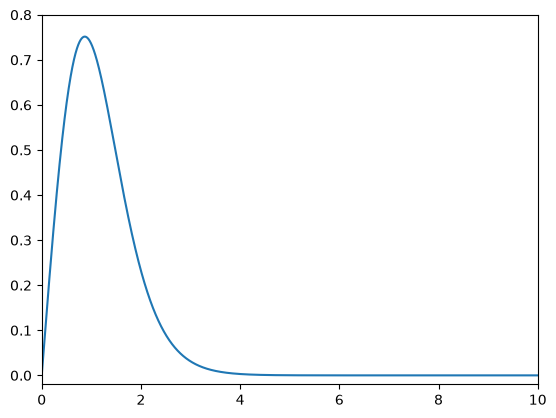

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data=np.load("Perfil_radialn0.npz")

plt.plot(data["radio"],data["perfil"])
plt.ylim(-0.02, 0.8)
plt.xlim(0.0,10)

C:\Users\SEARS\AppData\Local\Temp\ipykernel_11364\1385869398.py:26: RuntimeWarning: divide by zero encountered in power
  return A * (r**n) * np.exp(-b*r**m)


=========== ANALISIS DE AJUSTE ===========

--- Exponencial ---
MSE  = 0.0010147050024737726
RMSE = 0.03185443458097746
R²   = 0.9661441907401086

--- Gaussiano ---
MSE  = 3.206494727802926e-05
RMSE = 0.005662591922258681
R²   = 0.9989301474454872

--- General ---
MSE  = 4.40985890600969e-06
RMSE = 0.002099966405924078
R²   = 0.9998528642890092

=========== PARAMETROS ===========

Exponencial:
A = 8.047034226220653
b = 2.1400033054386025

Gaussiano:
A = 3.9116110806476856
b = 1.254326858688608

General:
A = 5.125923491262732
b = 1.5526046775560323
n = 1.118251604582468
m = 1.6712381358483743



d:\Physics\lensing-project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


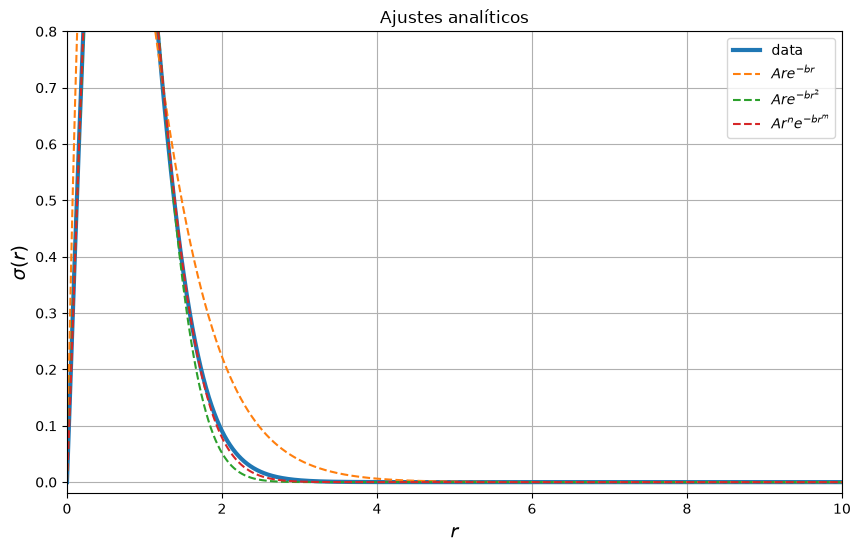

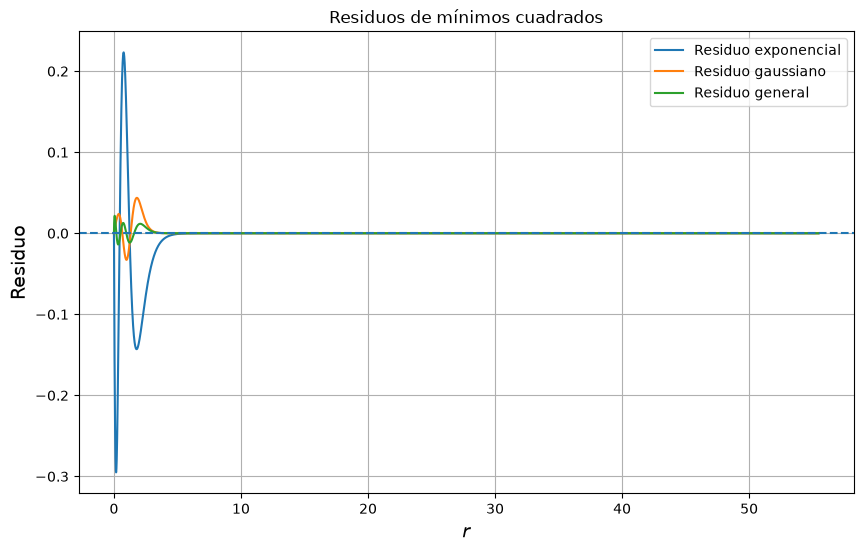

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# CARGAR DATOS
# ============================================================

lambd=2
data = np.load("Perfil_radialn0.npz")

r = lambd**(-1/2)*data["radio"]
perfil = lambd*data["perfil"]

# ============================================================
# MODELOS
# ============================================================

def model_exp(r, A, b):
    return A * r * np.exp(-b*r)

def model_gauss(r, A, b):
    return A * r * np.exp(-b*r**2)

def model_general(r, A, b, n, m):
    return A * (r**n) * np.exp(-b*r**m)

# ============================================================
# AJUSTES
# ============================================================

popt_exp, _ = curve_fit(
    model_exp,
    r,
    perfil,
    p0=[1,1]
)

popt_gauss, _ = curve_fit(
    model_gauss,
    r,
    perfil,
    p0=[1,1]
)

popt_general, _ = curve_fit(
    model_general,
    r,
    perfil,
    p0=[1,1,1,2],
    maxfev=20000
)

# ============================================================
# CURVAS AJUSTADAS
# ============================================================

fit_exp = model_exp(r, *popt_exp)

fit_gauss = model_gauss(r, *popt_gauss)

fit_general = model_general(r, *popt_general)

# ============================================================
# ANALISIS DE MINIMOS CUADRADOS
# ============================================================

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

# ============================================================
# RESULTADOS
# ============================================================

print("=========== ANALISIS DE AJUSTE ===========\n")

models = {
    "Exponencial": fit_exp,
    "Gaussiano": fit_gauss,
    "General": fit_general
}

for name, fit in models.items():

    print(f"--- {name} ---")

    print("MSE  =", mse(perfil, fit))
    print("RMSE =", rmse(perfil, fit))
    print("R²   =", r2_score(perfil, fit))

    print()

# ============================================================
# PARAMETROS
# ============================================================

print("=========== PARAMETROS ===========\n")

print("Exponencial:")
print(f"A = {popt_exp[0]}")
print(f"b = {popt_exp[1]}\n")

print("Gaussiano:")
print(f"A = {popt_gauss[0]}")
print(f"b = {popt_gauss[1]}\n")

print("General:")
print(f"A = {popt_general[0]}")
print(f"b = {popt_general[1]}")
print(f"n = {popt_general[2]}")
print(f"m = {popt_general[3]}\n")

# ============================================================
# RESIDUOS
# ============================================================

res_exp = perfil - fit_exp
res_gauss = perfil - fit_gauss
res_general = perfil - fit_general

# ============================================================
# GRAFICA PRINCIPAL
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(r, perfil,
         linewidth=3,
         label="data")

plt.plot(r, fit_exp,
         '--',
         label=r'$Ar e^{-br}$')

plt.plot(r, fit_gauss,
         '--',
         label=r'$Ar e^{-br^2}$')

plt.plot(r, fit_general,
         '--',
         label=r'$Ar^n e^{-br^m}$')

plt.xlim(0,10)
plt.ylim(-0.02,0.8)

plt.xlabel(r"$r$", fontsize=14)
plt.ylabel(r"$\sigma(r)$", fontsize=14)

plt.title("Ajustes analíticos")

plt.grid(True)

plt.legend()

plt.show()

# ============================================================
# GRAFICA DE RESIDUOS
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(r, res_exp,
         label="Residuo exponencial")

plt.plot(r, res_gauss,
         label="Residuo gaussiano")

plt.plot(r, res_general,
         label="Residuo general")

plt.axhline(0, linestyle='--')

plt.xlabel(r"$r$", fontsize=14)
plt.ylabel("Residuo", fontsize=14)

plt.title("Residuos de mínimos cuadrados")

plt.grid(True)

plt.legend()

plt.show()

===== ERRORES =====
Exponencial: 0.0002536762506268569
Gaussiano: 8.016236819301097e-06
General: 1.1024647265005528e-06

===== PARAMETROS =====

Exponencial:
[2.84505706 1.51321114]

Gaussiano:
[1.38296348 0.6271635 ]

General:
[1.73951609 0.86999036 1.11825156 1.67123824]


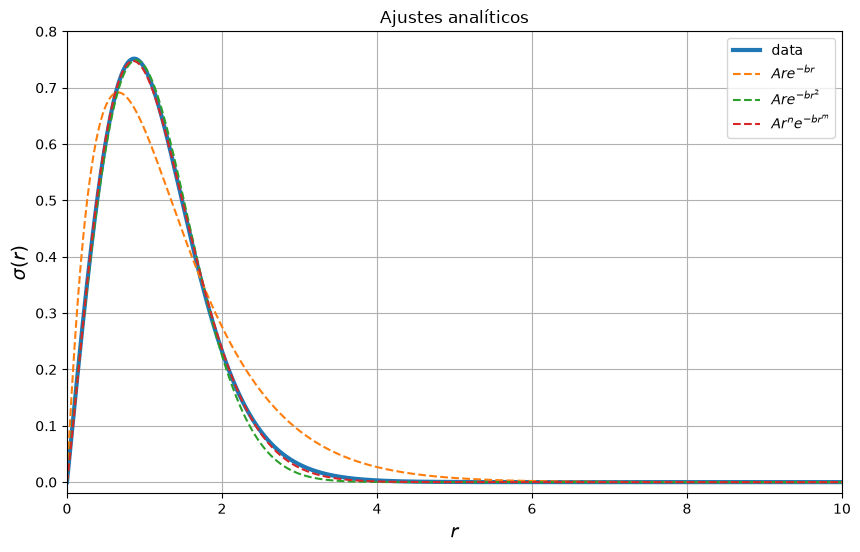

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# CARGAR DATOS
# ============================================================

data = np.load("Perfil_radialn0.npz")

r = data["radio"]
perfil = data["perfil"]

# ============================================================
# MODELOS
# ============================================================

# A r exp(-b r)
def model_exp(r, A, b):
    return A * r * np.exp(-b*r)

# A r exp(-b r^2)
def model_gauss(r, A, b):
    return A * r * np.exp(-b*r**2)

# A r^n exp(-b r^m)
def model_general(r, A, b, n, m):
    return A * (r**n) * np.exp(-b*r**m)

# ============================================================
# AJUSTES
# ============================================================

# Ajuste exponencial
popt_exp, _ = curve_fit(
    model_exp,
    r,
    perfil,
    p0=[1,1]
)

# Ajuste gaussiano
popt_gauss, _ = curve_fit(
    model_gauss,
    r,
    perfil,
    p0=[1,1]
)

# Ajuste general
popt_general, _ = curve_fit(
    model_general,
    r,
    perfil,
    p0=[1,1,1,2],
    maxfev=20000
)

# ============================================================
# CURVAS AJUSTADAS
# ============================================================

fit_exp = model_exp(r, *popt_exp)

fit_gauss = model_gauss(r, *popt_gauss)

fit_general = model_general(r, *popt_general)

# ============================================================
# ERRORES
# ============================================================

def mse(real, ajuste):
    return np.mean((real-ajuste)**2)

print("===== ERRORES =====")

print("Exponencial:", mse(perfil, fit_exp))

print("Gaussiano:", mse(perfil, fit_gauss))

print("General:", mse(perfil, fit_general))

# ============================================================
# PARAMETROS
# ============================================================

print("\n===== PARAMETROS =====")

print("\nExponencial:")
print(popt_exp)

print("\nGaussiano:")
print(popt_gauss)

print("\nGeneral:")
print(popt_general)

# ============================================================
# GRAFICA
# ============================================================

plt.figure(figsize=(10,6))

# Datos
plt.plot(r, perfil,
         linewidth=3,
         label="data")

# Ajustes
plt.plot(r, fit_exp,
         '--',
         label=r'$Ar e^{-br}$')

plt.plot(r, fit_gauss,
         '--',
         label=r'$Ar e^{-br^2}$')

plt.plot(r, fit_general,
         '--',
         label=r'$Ar^n e^{-br^m}$')

plt.xlim(0,10)
plt.ylim(-0.02,0.8)

plt.xlabel(r"$r$", fontsize=14)
plt.ylabel(r"$\sigma(r)$", fontsize=14)

plt.title("Ajustes analíticos")

plt.grid(True)

plt.legend()

plt.show()